Step 1 — GPU Check

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


Step 2 — Install Libraries

In [2]:
%pip install -q torch torchvision timm
%pip install -q opencv-python-headless
%pip install -q albumentations
%pip install -q matplotlib pandas tqdm scikit-learn

Step 3 — Kaggle Dataset Download

In [4]:
!pip install kaggle

from google.colab import files
files.upload()   # kaggle.json upload karo

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

!unzip 140k-real-and-fake-faces.zip

Streaming output truncated to the last 5000 lines.
  inflating: real_vs_fake/real-vs-fake/valid/real/34832.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34836.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34839.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34847.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34848.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34852.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34861.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34864.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34883.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34887.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34891.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34894.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34904.jpg  
  inflating: real_v

Check dataset

In [5]:
!find /content -type d | grep real-vs-fake | head -20

/content/real_vs_fake/real-vs-fake
/content/real_vs_fake/real-vs-fake/test
/content/real_vs_fake/real-vs-fake/test/real
/content/real_vs_fake/real-vs-fake/test/fake
/content/real_vs_fake/real-vs-fake/valid
/content/real_vs_fake/real-vs-fake/valid/real
/content/real_vs_fake/real-vs-fake/valid/fake
/content/real_vs_fake/real-vs-fake/train
/content/real_vs_fake/real-vs-fake/train/real
/content/real_vs_fake/real-vs-fake/train/fake


Step 4 — Imports

In [6]:
import torch
import torch.nn as nn
import timm

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

Step 5 — Parameters

In [7]:
IMAGE_SIZE = 380
BATCH_SIZE = 16
EPOCHS = 10

Step 6 — Data Augmentation

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

Step 7 — Dataset Reduce

In [9]:
import os
import shutil
import random

SOURCE = "/content/real_vs_fake/real-vs-fake/train"
DEST = "/content/small_dataset"

os.makedirs(f"{DEST}/real", exist_ok=True)
os.makedirs(f"{DEST}/fake", exist_ok=True)

for cls in ["real", "fake"]:

    files = os.listdir(f"{SOURCE}/{cls}")

    random.shuffle(files)

    selected = files[:1000]

    for f in selected:

        shutil.copy(
            f"{SOURCE}/{cls}/{f}",
            f"{DEST}/{cls}/{f}"
        )

print("Dataset Reduced Successfully")

Dataset Reduced Successfully


Step 8 — Load Training Dataset

In [10]:
train_dataset = datasets.ImageFolder(
    "/content/small_dataset",
    transform=train_transform
)

Step 9 — Initialize Model on GPU (T4)

In [11]:
import timm
import torch

# GPU available hai to CUDA use karega
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Using Device: cuda
GPU: Tesla T4


Step 10 — Verify GPU Availability (Tesla T4)

In [12]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


Step 11 — Define Loss Function and Optimizer

In [13]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

print("Optimizer Ready")

Optimizer Ready


Step 12 — Define Image Transformations

In [14]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((380,380)),
    transforms.ToTensor()
])

Step 13 — Verify Dataset Location

In [15]:
!ls /content

140k-real-and-fake-faces.zip  real_vs_fake  small_dataset  train.csv
kaggle.json		      sample_data   test.csv	   valid.csv


Step 14 — Load Training Dataset

In [16]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    "/content/small_dataset",
    transform=train_transform
)

print("Images:", len(train_dataset))

Images: 2000


Step 15 — Create DataLoader

In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print("Train Loader Ready")

Train Loader Ready


Step 16 — Load Deepfake Detection Model

In [18]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU: Tesla T4


Step 17 — Define Loss Function and Optimizer

In [19]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

print("Optimizer Ready")

Optimizer Ready


Step 18 — Train Deepfake Dataset Model

In [20]:
from tqdm import tqdm

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Loss: {running_loss/len(train_loader):.4f}")

100%|██████████| 250/250 [01:27<00:00,  2.86it/s]



Epoch 1/5
Loss: 0.5462


100%|██████████| 250/250 [01:26<00:00,  2.91it/s]



Epoch 2/5
Loss: 0.1527


100%|██████████| 250/250 [01:27<00:00,  2.86it/s]



Epoch 3/5
Loss: 0.0727


100%|██████████| 250/250 [01:28<00:00,  2.84it/s]



Epoch 4/5
Loss: 0.0352


100%|██████████| 250/250 [01:28<00:00,  2.82it/s]


Epoch 5/5
Loss: 0.0186


Step 19 — Save Trained Model

In [21]:
torch.save(model.state_dict(), "deepfake_model.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
torch.save(model.state_dict(), "deepfake_model.pth")

print("Model Saved")

Model Saved


Step 20 — Download Trained Model

In [23]:
from google.colab import files
files.download("deepfake_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
!ls

140k-real-and-fake-faces.zip  kaggle.json   sample_data    test.csv   valid.csv
deepfake_model.pth	      real_vs_fake  small_dataset  train.csv


Step 21 — Upload Test Image

In [25]:
from google.colab import files

uploaded = files.upload()

Saving 20241219_122317.jpg to 20241219_122317.jpg


Step 22 — Predict Real or Fake Image

In [26]:
from PIL import Image
from torchvision import transforms
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model load
model = timm.create_model(
    "efficientnet_b4",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(torch.load("deepfake_model.pth"))
model = model.to(device)
model.eval()

# Image path
image_path = list(uploaded.keys())[0]

img = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((380,380)),
    transforms.ToTensor()
])

x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(x)
    pred = output.argmax(1).item()

if pred == 0:
    print("FAKE")
else:
    print("REAL")

REAL


In [27]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)

['fake', 'real']
{'fake': 0, 'real': 1}


Step 23 — Upload Test Video

In [28]:
from google.colab import files

uploaded = files.upload()

Saving InShot_20240325_090304575.mp4 to InShot_20240325_090304575.mp4


Step 24 — Predict Real or Fake Image

In [29]:
import cv2
import numpy as np
from PIL import Image
import torch

video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)

scores = []
frame_no = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    if frame_no % 15 == 0:

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        img = Image.fromarray(frame)

        x = transform(img)

        x = x.unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(x)

            prob = torch.softmax(
                output,
                dim=1
            )[0][0].item()   # fake class

        scores.append(prob)

    frame_no += 1

cap.release()

score = np.mean(scores)

print("Fake Probability =", score)

if score > 0.5:
    print("VIDEO = FAKE")
else:
    print("VIDEO = REAL")

Fake Probability = 0.019181510468506306
VIDEO = REAL


Step 25 — Save Model

In [30]:
from google.colab import files
files.download('/content/deepfake_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 26 — Save Model on Huggingface

In [31]:
!pip install -q huggingface_hub
from huggingface_hub import login, HfApi
login()   # token paste karo

api = HfApi()
api.create_repo("deepfake-detector-model", repo_type="model", exist_ok=True)
api.upload_file(
    path_or_fileobj="/content/deepfake_model.pth",
    path_in_repo="deepfake_model.pth",
    repo_id="mohitbharti1530/deepfake-detector-model",
    repo_type="model",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/deepfake_model.pth :   1%|          |  553kB / 71.0MB            

CommitInfo(commit_url='https://huggingface.co/mohitbharti1530/deepfake-detector-model/commit/715e985b8be5ab1ae748b391f7c12ec7218aba80', commit_message='Upload deepfake_model.pth with huggingface_hub', commit_description='', oid='715e985b8be5ab1ae748b391f7c12ec7218aba80', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mohitbharti1530/deepfake-detector-model', endpoint='https://huggingface.co', repo_type='model', repo_id='mohitbharti1530/deepfake-detector-model'), pr_revision=None, pr_num=None)

Step 27 — Test data load karo

In [32]:
import torch, numpy as np
from torchvision import datasets
from torch.utils.data import DataLoader, Subset

device = 'cuda' if torch.cuda.is_available() else 'cpu'

test_root = '/content/real_vs_fake/real-vs-fake/test'   # path !ls se check kar lena
test_ds = datasets.ImageFolder(test_root, transform=transform)  # tfm = tumhara training/val wala transform
print(test_ds.class_to_idx)    # aksar {'fake': 0, 'real': 1}

# Time bachana ho to subset (optional):
# idx = np.random.choice(len(test_ds), 5000, replace=False); test_ds = Subset(test_ds, idx)

test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

{'fake': 0, 'real': 1}


Step 27 — Predictions nikalo

In [33]:
model.eval().to(device)
y_true, y_prob = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        out = model(x)
        if out.shape[1] == 1:
            p = torch.sigmoid(out).squeeze(1)
        else:
            p = torch.softmax(out, 1)[:, 1]
        y_prob.extend(p.cpu().numpy())
        y_true.extend(y.numpy())

y_true = np.array(y_true); y_prob = np.array(y_prob)

Step 28 — Metrics

In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_auc_score)

MODEL_OUTPUT_IS_FAKE_PROB = False

FAKE_IDX = test_ds.class_to_idx['fake'] if not isinstance(test_ds, torch.utils.data.Subset) \
           else test_ds.dataset.class_to_idx['fake']

y_true_fake = (y_true == FAKE_IDX).astype(int)

if MODEL_OUTPUT_IS_FAKE_PROB:
    score = y_prob
else:
    score = 1 - y_prob

y_pred = (score > 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_true_fake, y_pred), 4))
print("Precision:", round(precision_score(y_true_fake, y_pred), 4))
print("Recall   :", round(recall_score(y_true_fake, y_pred), 4))
print("F1-score :", round(f1_score(y_true_fake, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_true_fake, score), 4))
print("\nConfusion matrix [rows=true, cols=pred] (0=Real, 1=Fake):\n", confusion_matrix(y_true_fake, y_pred))
print("\n", classification_report(y_true_fake, y_pred, target_names=['Real','Fake']))

Accuracy : 0.9413
Precision: 0.9596
Recall   : 0.9213
F1-score : 0.9401
ROC-AUC  : 0.9873

Confusion matrix [rows=true, cols=pred] (0=Real, 1=Fake):
 [[9612  388]
 [ 787 9213]]

               precision    recall  f1-score   support

        Real       0.92      0.96      0.94     10000
        Fake       0.96      0.92      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



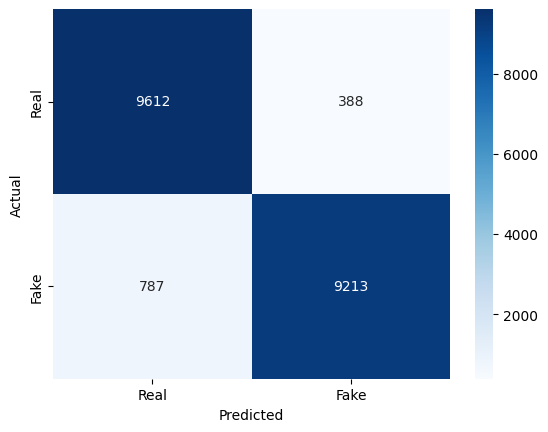

In [37]:
import seaborn as sns, matplotlib.pyplot as plt
cm = confusion_matrix(y_true_fake, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()